# Machine Learning

In [1]:
# Machine Learning for EEG Feature Classification

# basic
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# notebook display
%matplotlib inline
sns.set_theme(style="whitegrid")

c:\Users\15122\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


读取数据

In [2]:
feature_df = pd.read_csv("E:\EEG_project\data\processed\subject01_features.csv")

print(feature_df.shape)
feature_df.head()

(286, 360)


,Fp1_delta,Fp2_delta,F3_delta,F4_delta,C3_delta,C4_delta,P3_delta,P4_delta,O1_delta,O2_delta,...,parietal_theta_alpha_ratio,parietal_delta_alpha_ratio,temporal_theta_beta_ratio,temporal_alpha_beta_ratio,temporal_theta_alpha_ratio,temporal_delta_alpha_ratio,occipital_theta_beta_ratio,occipital_alpha_beta_ratio,occipital_theta_alpha_ratio,occipital_delta_alpha_ratio
0,-1.310930,-1.044057,-1.259704,-1.007682,-1.149320,-0.515209,-0.836206,-0.874192,-2.028693,-0.305758,...,0.641766,0.323491,1.238929,1.371608,0.903268,0.113207,1.043227,1.487109,0.701514,0.429605
1,-0.177707,-0.510573,-0.972117,-0.387270,-0.497661,-0.589908,-0.855177,-0.611738,-0.613392,-1.274785,...,0.734342,0.358642,0.838637,1.144519,0.732742,0.272636,0.617651,0.844062,0.731759,0.549643
2,-3.312816,-0.896658,-1.671914,-1.148300,-0.796402,-0.600296,-1.080035,-0.462435,-1.182772,-1.238946,...,0.922761,0.391086,1.360746,1.488252,0.914325,0.346253,2.019874,2.292912,0.880921,0.471736
3,-2.512582,-0.932189,-2.286642,-0.929797,-1.350020,-0.982329,-0.742956,-0.889003,-1.203754,-0.546215,...,0.764590,0.371535,1.127356,1.120922,1.005740,0.560041,2.028186,2.007456,1.010327,0.352284
4,-2.713897,-1.780116,-1.572438,-1.099905,-0.630580,-0.596021,-1.299483,-0.392364,-0.857162,-1.536077,...,1.031886,0.532809,1.154010,1.486789,0.776176,0.276436,1.843907,1.274732,1.446505,0.727400


# 准备阶段

创建人工标签
high_alpha / low_alpha

In [3]:
# ===== 检查是否存在 alpha_power =====

if "alpha_power" in feature_df.columns:
    print("alpha_power 已存在")
else:
    print("alpha_power 不存在，需要创建")

alpha_power 不存在，需要创建


In [4]:
# ===== 自动查找所有 alpha 相关列 =====

alpha_cols = [col for col in feature_df.columns if "alpha" in col.lower()]

print("检测到的 alpha 列：", alpha_cols)


# ===== 创建 alpha_power（多通道平均）=====

feature_df["alpha_power"] = feature_df[alpha_cols].mean(axis=1)

print("alpha_power 已创建")

检测到的 alpha 列： ['Fp1_alpha', 'Fp2_alpha', 'F3_alpha', 'F4_alpha', 'C3_alpha', 'C4_alpha', 'P3_alpha', 'P4_alpha', 'O1_alpha', 'O2_alpha', 'F7_alpha', 'F8_alpha', 'T7_alpha', 'T8_alpha', 'P7_alpha', 'P8_alpha', 'Fz_alpha', 'Cz_alpha', 'Pz_alpha', 'FC1_alpha', 'FC2_alpha', 'CP1_alpha', 'CP2_alpha', 'FC5_alpha', 'FC6_alpha', 'CP5_alpha', 'CP6_alpha', 'FT9_alpha', 'FT10_alpha', 'TP9_alpha', 'TP10_alpha', 'F1_alpha', 'F2_alpha', 'C1_alpha', 'C2_alpha', 'P1_alpha', 'P2_alpha', 'AF3_alpha', 'AF4_alpha', 'FC3_alpha', 'FC4_alpha', 'CP3_alpha', 'CP4_alpha', 'PO3_alpha', 'PO4_alpha', 'F5_alpha', 'F6_alpha', 'C5_alpha', 'C6_alpha', 'P5_alpha', 'P6_alpha', 'AF7_alpha', 'AF8_alpha', 'FT7_alpha', 'FT8_alpha', 'TP7_alpha', 'TP8_alpha', 'PO7_alpha', 'PO8_alpha', 'Fpz_alpha', 'CPz_alpha', 'POz_alpha', 'Oz_alpha', 'frontal_alpha', 'central_alpha', 'parietal_alpha', 'temporal_alpha', 'occipital_alpha', 'frontal_alpha_beta_ratio', 'frontal_theta_alpha_ratio', 'frontal_delta_alpha_ratio', 'central_alpha_beta

In [5]:
feature_df[["alpha_power"]].head()

,alpha_power
0,-2.016960
1,-1.785378
2,-1.809636
3,-1.697861
4,-1.788714


In [6]:
# =====  构建标签（high_alpha / low_alpha） =====

# 用 alpha_power 的中位数作为阈值
threshold = feature_df["alpha_power"].median()

# 构建标签
feature_df["label"] = feature_df["alpha_power"].apply(
    lambda x: "high_alpha" if x > threshold else "low_alpha"
)

# 查看分布
print(feature_df["label"].value_counts())

label
low_alpha     143
high_alpha    143
Name: count, dtype: int64


In [7]:
# 定义特征和标签
X = feature_df.drop(columns=["label","alpha_power"])
y = feature_df["label"]

print(X.shape)
print(y.shape)

(286, 360)
(286,)


# 定义模型

In [8]:
# separate features and label

# ===== 时间划分（temporal split） =====

split_idx = int(len(X) * 0.7)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (200, 360)
Test size: (86, 360)


In [9]:
# 特征标准化（只针对train数据）
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 比较不同模型

In [10]:
#时间序列交叉验证（只在训练集内部）
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

In [11]:
# 模型定义
# models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

lr_model = LogisticRegression(max_iter=1000)
svm_model = SVC(kernel='rbf', C=1.0, probability=True)  # probability=True为了ROC
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# CV评分
lr_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=tscv, scoring='accuracy')
svm_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=tscv, scoring='accuracy')
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=tscv, scoring='accuracy')

print("LR:", lr_scores, "mean:", lr_scores.mean())
print("SVM:", svm_scores, "mean:", svm_scores.mean())
print("RF:", rf_scores, "mean:", rf_scores.mean())

LR: [0.81818182 0.87878788 0.96969697 0.96969697 0.90909091] mean: 0.9090909090909092
SVM: [0.81818182 0.90909091 0.96969697 0.81818182 0.90909091] mean: 0.884848484848485
RF: [0.84848485 0.93939394 1.         0.96969697 0.96969697] mean: 0.9454545454545455


In [12]:
# 选择最佳模型

mean_scores = {
    "Logistic Regression": lr_scores.mean(),
    "SVM": svm_scores.mean(),
    "Random Forest": rf_scores.mean()
}

best_model_name = max(mean_scores, key=mean_scores.get)
print("\nBest model:", best_model_name)


Best model: Random Forest


In [13]:
# 在整个训练集上重新训练最佳模型
if best_model_name == "Logistic Regression":
    best_model = LogisticRegression(max_iter=1000)
    best_model.fit(X_train_scaled, y_train)
    X_test_used = X_test_scaled

elif best_model_name == "SVM":
    best_model = SVC(kernel='rbf', C=1.0, probability=True)
    best_model.fit(X_train_scaled, y_train)
    X_test_used = X_test_scaled

else:
    best_model = RandomForestClassifier(n_estimators=100, random_state=42)
    best_model.fit(X_train, y_train)
    X_test_used = X_test_scaled

# 评估最终验证集

In [14]:
# Accuracy + Classification Report
from sklearn.metrics import accuracy_score, classification_report

y_pred = best_model.predict(X_test_used)

print("\n=== Final Test Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


=== Final Test Performance ===
Accuracy: 0.7093023255813954
              precision    recall  f1-score   support

  high_alpha       0.65      0.70      0.68        37
   low_alpha       0.76      0.71      0.74        49

    accuracy                           0.71        86
   macro avg       0.71      0.71      0.71        86
weighted avg       0.71      0.71      0.71        86



c:\Users\15122\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


模型准确率约为0.71，high alpha类别的召回率为0.70，表明模型能够较稳定地识别目标状态。整体precision和recall较为均衡，说明模型不存在明显类别偏置，但仍有一定提升空间。

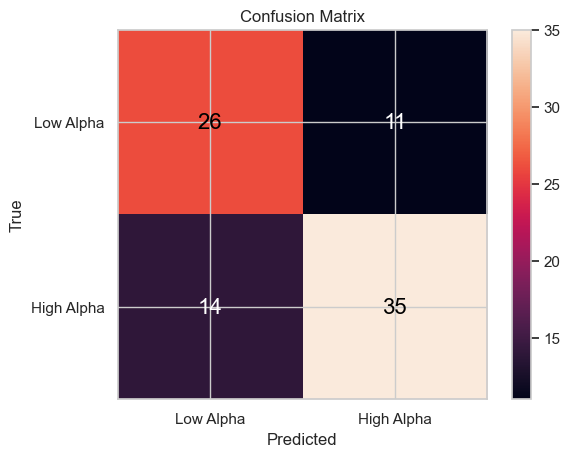

In [15]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

ticks = np.arange(2)
plt.xticks(ticks, ["Low Alpha", "High Alpha"])
plt.yticks(ticks, ["Low Alpha", "High Alpha"])

thresh = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        # 根据阈值来设置颜色
        color = "white" if value < thresh else "black"
        plt.text(
            j, i, value,
            ha="center", va="center",
            color=color,
            fontsize=16  # 调大字号，比如 12～16 
        )

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [16]:
print(best_model.classes_)

['high_alpha' 'low_alpha']


c:\Users\15122\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


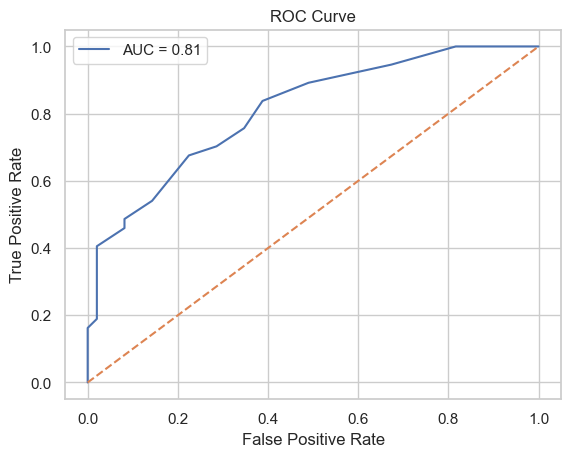

In [17]:
# ROC 曲线 + AUC
from sklearn.metrics import roc_curve, auc

# 概率预测
y_prob = best_model.predict_proba(X_test_used)[:, 0] # 注意这里哪个是“作为正类的那个类别"

fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label='high_alpha')
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

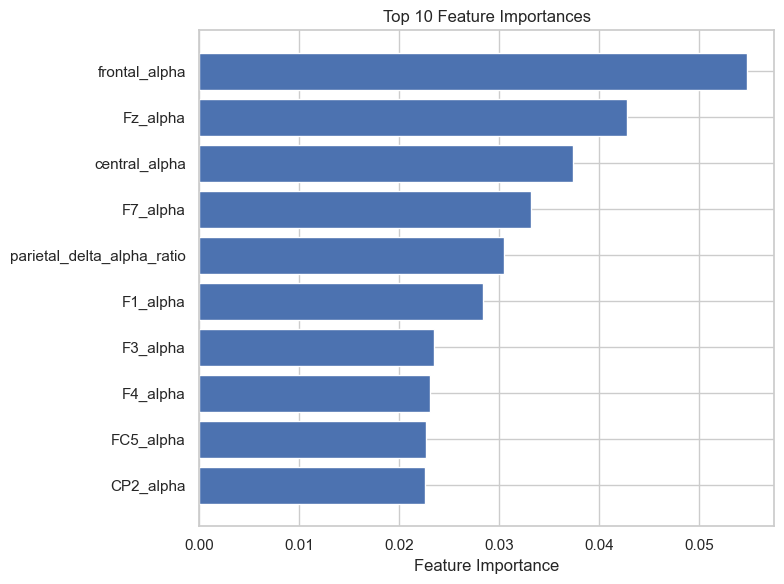

In [18]:
# Feature Importance（RF专属）只有当 RF 被选中才有意义
if best_model_name == "Random Forest":
    importances = best_model.feature_importances_
    feature_names = X.columns

    N = 10  # 想看前多少个可以改这个数
    indices = np.argsort(importances)[::-1]  # 从大到小排序后的索引
    top_indices = indices[:N]

    top_importances = importances[top_indices]
    top_features = feature_names[top_indices]

    # 3. 画图（横向条形图，更容易看清）
    plt.figure(figsize=(8, 6))  # 可以调整大小
    plt.barh(range(N), top_importances[::-1], align='center')  # 反转一下，让最重要的在最上面
    plt.yticks(range(N), top_features[::-1])
    plt.xlabel("Feature Importance")
    plt.title(f"Top {N} Feature Importances")
    plt.tight_layout()
    plt.show()